In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re 
import warnings
warnings.filterwarnings('ignore')
from nltk.corpus import stopwords
from dateutil import parser
from datetime import datetime 
from sklearn.feature_extraction.text import TfidfVectorizer

In [3]:
df = pd.read_csv('emotions_dataset.csv')

In [4]:
df.head()

,id,text,example_very_unclear,admiration,amusement,anger,annoyance,approval,caring,confusion,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,eew5j0j,That game hurt.,False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,eemcysk,>sexuality shouldn’t be a grouping category I...,True,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,ed2mah1,"You do right, if you don't care then fuck 'em!",False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,eeibobj,Man I love reddit.,False,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,eda6yn6,"[NAME] was nowhere near them, he was by the Fa...",False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [5]:
df.drop(columns=['id'], inplace=True)

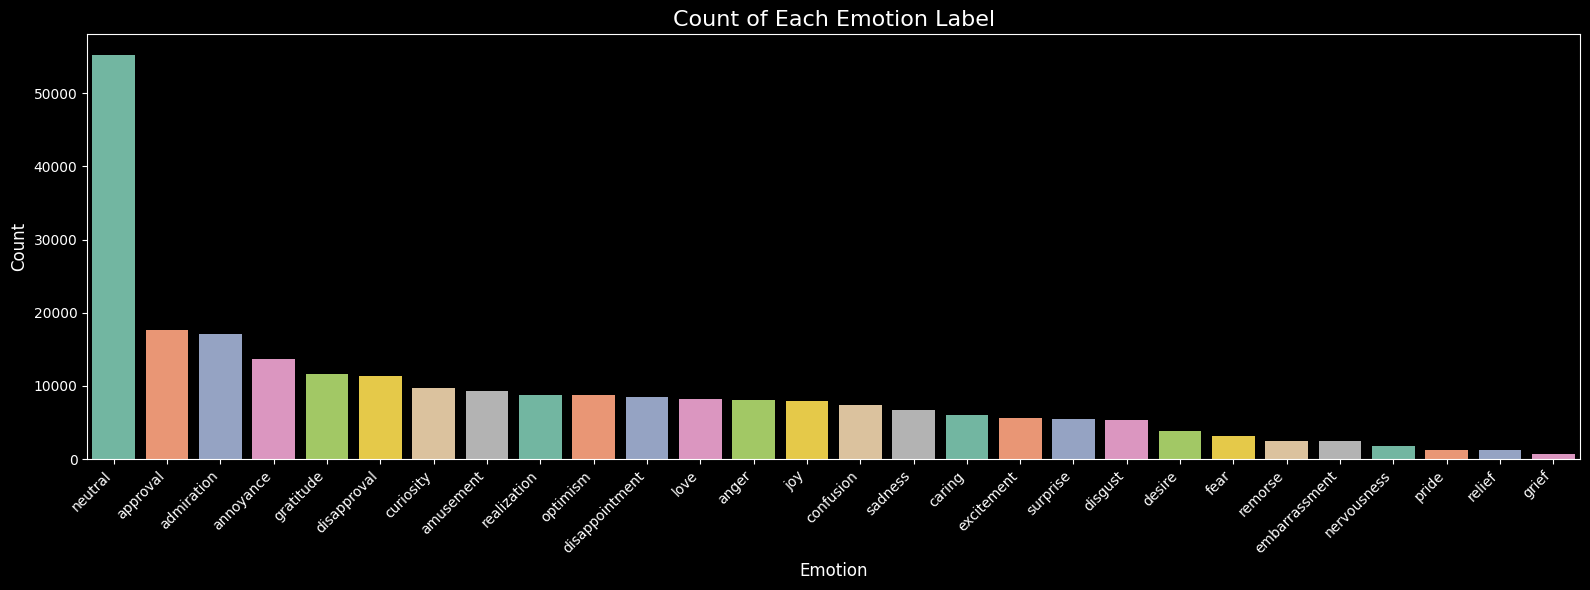

In [6]:
emotion_counts = df.drop(columns=['text', 'example_very_unclear']).sum().sort_values(ascending=False)

# Plot with dark theme
plt.style.use('dark_background')
plt.figure(figsize=(16, 6))
sns.barplot(x=emotion_counts.index, y=emotion_counts.values, palette='Set2')

plt.title('Count of Each Emotion Label', fontsize=16, color='white')
plt.xlabel('Emotion', fontsize=12, color='white')
plt.ylabel('Count', fontsize=12, color='white')
plt.xticks(rotation=45, ha='right', color='white')
plt.yticks(color='white')
plt.tight_layout()
plt.show()

1. Text Preprocessing

In [7]:
slang_df = pd.read_csv('Slang.txt', sep="=", names=["abbreviation", "phrase"], header=None)
slang_df.head()

,abbreviation,phrase
0,A3,"Anytime, Anywhere, Anyplace"
1,ADIH,Another Day In Hell
2,AFK,Away From Keyboard
3,AFAIK,As Far As I Know
4,ASAP,As Soon As Possible


In [8]:
slang_dict = dict(zip(slang_df['abbreviation'], slang_df['phrase'])) 

In [9]:
def translate_slang(text):
    count = 0
    words = text.split()
    new_words = []
    for word in words:
        clean_word = re.sub('[^a-zA-Z0-9-_.]', '', word).upper()
        if clean_word in slang_dict:
            count += 1
            translate_word = slang_dict.get(clean_word, word)
            new_words.append(translate_word)
        else:
            new_words.append(word)
            
    result = ' '.join(new_words)
    
    return result.lower(), count   
 
texts, counts = zip(*df['text'].apply(translate_slang))
df['text'] = texts
df['slang_count'] = counts

In [10]:
df['slang_count'].sum()

np.int64(14163)

2. Handling Temporal Data

In [11]:
def temp_data(text):
    if not isinstance(text, str) or not text:
        return ""
    
    else:
        date_pattern = r'(\d{1,2}\s?[/\-]\s?\d{1,2}\s?[/\-]\s?\d{2,4})|([A-Za-z]{3,9}\s\d{1,2}\s\d{4})'
        def transform_date(match):
            date_str = match.group(0)
            clean_date = re.sub(r'\s+', '', date_str)
            try:
                dt = parser.parse(clean_date, default=datetime(2025, 1, 1))
                return dt.strftime(" %B %d %Y ").lower()
            except:
                return " date_token "
            
        time_pattern = r'\d{1,2}\s?:\s?\d{2}(\s?[ap]m)?'
    
        def transform_time(match):
            time_str = match.group(0).lower()
            clean_time = re.sub(r'\s+', '', time_str)
            try:
                if 'm' in clean_time:
                    parts = clean_time.replace('am', '').replace('pm', '').split(':')
                    hour = int(parts[0])
                    if 'pm' in clean_time and hour != 12:
                        hour += 12
                    elif 'am' in clean_time and hour == 12:
                        hour = 0
                    return f" hour_{hour} "
                return " time_token "
            except:
                return " time_token "

        text = re.sub(date_pattern, transform_date, text)  
        text = re.sub(time_pattern, transform_time, text)  
        
        return " ".join(text.split())
    
df['text'] = df['text'].apply(temp_data)

In [12]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger_eng')

lemmatizer = WordNetLemmatizer()

def get_pos(tag):
    if tag.startswith('V'): return wordnet.VERB
    if tag.startswith('J'): return wordnet.ADJ
    if tag.startswith('R'): return wordnet.ADV
    return wordnet.NOUN

def tokenize_and_lemmatize(text):
    if not isinstance(text, str) or not text:
        return ""
    
    tokens = word_tokenize(text)
    pos_tags = nltk.pos_tag(tokens)
    lemmas = [lemmatizer.lemmatize(word, get_pos(tag)) for word, tag in pos_tags]
    return " ".join(lemmas)

text = "that game was really hurting my feelings"
print(tokenize_and_lemmatize(text))

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


that game be really hurt my feeling


In [13]:
df['text'] = df['text'].apply(tokenize_and_lemmatize)

3. Applying Word2Vec Text Representation

In [15]:
df = df[df['text'].str.strip() != ""]

# TF-IDF Vectorization
vectorizer = TfidfVectorizer(
    max_features=5000,   # keep top 5000 words
    ngram_range=(1, 2),  # include single words and bigrams
    min_df=2,            # ignore words that appear in less than 2 documents
    sublinear_tf=True    # scale term frequency logarithmically
)

X = vectorizer.fit_transform(df['text'])
y = df.drop(columns=['text', 'example_very_unclear'])

print(f"Feature matrix shape: {X.shape}")
print(f"Output shape: {y.shape}")

Feature matrix shape: (211225, 5000)
Output shape: (211225, 29)


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import numpy as np

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train
lr_model = MultiOutputClassifier(LogisticRegression(max_iter=1000))
lr_model.fit(X_train, y_train)

# Predict
y_pred = lr_model.predict(X_test)

# ---- Fix: convert to numpy arrays first ----
y_test_array = np.array(y_test)
y_pred_array = np.array(y_pred)

# Evaluate each emotion separately
emotion_columns = y.columns.tolist()
for i, emotion in enumerate(emotion_columns):
    print(f"\n--- {emotion} ---")
    print(classification_report(y_test_array[:, i], y_pred_array[:, i], zero_division=0))


--- admiration ---
              precision    recall  f1-score   support

           0       0.94      0.99      0.96     38789
           1       0.70      0.28      0.40      3456

    accuracy                           0.93     42245
   macro avg       0.82      0.63      0.68     42245
weighted avg       0.92      0.93      0.92     42245


--- amusement ---
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     40354
           1       0.59      0.29      0.39      1891

    accuracy                           0.96     42245
   macro avg       0.78      0.64      0.68     42245
weighted avg       0.95      0.96      0.95     42245


--- anger ---
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     40617
           1       0.56      0.10      0.16      1628

    accuracy                           0.96     42245
   macro avg       0.76      0.55      0.57     42245
weighted avg       0

---

In [ ]:
# import torch
# import numpy as np
# import pandas as pd
# from torch.utils.data import Dataset, DataLoader
# from transformers import AutoTokenizer, AutoModelForSequenceClassification
# from torch.optim import AdamW
# from transformers import get_scheduler
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import classification_report

# # ---- Config ----
# MODEL_NAME = "bert-base-uncased"
# MAX_LEN = 128
# BATCH_SIZE = 32
# EPOCHS = 5
# LR = 2e-5
# NUM_LABELS = 29
# DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(f"Using device: {DEVICE}")

# # ---- Dataset Class ----
# class EmotionDataset(Dataset):
#     def __init__(self, texts, labels, tokenizer):
#         self.texts = texts
#         self.labels = labels
#         self.tokenizer = tokenizer

#     def __len__(self):
#         return len(self.texts)

#     def __getitem__(self, idx):
#         encoding = self.tokenizer(
#             self.texts[idx],
#             max_length=MAX_LEN,
#             padding='max_length',
#             truncation=True,
#             return_tensors='pt'
#         )
#         return {
#             'input_ids': encoding['input_ids'].squeeze(),
#             'attention_mask': encoding['attention_mask'].squeeze(),
#             'labels': torch.tensor(self.labels[idx], dtype=torch.float)
#         }

# # ---- Prepare Data ----
# df = df[df['text'].str.strip() != ""]

# texts = df['text'].tolist()
# labels = df.drop(columns=['id', 'text', 'example_very_unclear']).values.tolist()

# X_train, X_test, y_train, y_test = train_test_split(
#     texts, labels, test_size=0.2, random_state=42
# )

# # ---- Tokenizer ----
# tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# # ---- Dataloaders ----
# train_dataset = EmotionDataset(X_train, y_train, tokenizer)
# test_dataset  = EmotionDataset(X_test,  y_test,  tokenizer)

# train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
# test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

# # ---- Model ----
# model = AutoModelForSequenceClassification.from_pretrained(
#     MODEL_NAME,
#     num_labels=NUM_LABELS,
#     problem_type="multi_label_classification"
# )
# model.to(DEVICE)

# # ---- Optimizer & Scheduler ----
# optimizer = AdamW(model.parameters(), lr=LR)
# scheduler = get_scheduler(
#     "linear",
#     optimizer=optimizer,
#     num_warmup_steps=0,
#     num_training_steps=len(train_loader) * EPOCHS
# )

# # ---- Training Loop ----
# def train_epoch(model, loader):
#     model.train()
#     total_loss = 0
#     for batch in loader:
#         input_ids      = batch['input_ids'].to(DEVICE)
#         attention_mask = batch['attention_mask'].to(DEVICE)
#         labels         = batch['labels'].to(DEVICE)

#         outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
#         loss = outputs.loss

#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()
#         scheduler.step()

#         total_loss += loss.item()
#     return total_loss / len(loader)

# # ---- Evaluation ----
# def evaluate(model, loader):
#     model.eval()
#     all_preds, all_labels = [], []
#     with torch.no_grad():
#         for batch in loader:
#             input_ids      = batch['input_ids'].to(DEVICE)
#             attention_mask = batch['attention_mask'].to(DEVICE)
#             labels         = batch['labels'].to(DEVICE)

#             outputs = model(input_ids=input_ids, attention_mask=attention_mask)
#             preds = torch.sigmoid(outputs.logits)
#             preds = (preds > 0.5).int()  # threshold at 0.5

#             all_preds.append(preds.cpu().numpy())
#             all_labels.append(labels.cpu().numpy())

#     all_preds  = np.vstack(all_preds)
#     all_labels = np.vstack(all_labels)
#     return all_preds, all_labels

# # ---- Run Training ----
# for epoch in range(EPOCHS):
#     train_loss = train_epoch(model, train_loader)
#     print(f"Epoch {epoch+1}/{EPOCHS} — Loss: {train_loss:.4f}")

# # ---- Final Evaluation ----
# emotion_columns = df.drop(columns=['id', 'text', 'example_very_unclear']).columns.tolist()
# y_pred, y_true = evaluate(model, test_loader)
# print(classification_report(y_true, y_pred, target_names=emotion_columns))

# # ---- Save Model ----
# model.save_pretrained("emotion_bert_model")
# tokenizer.save_pretrained("emotion_bert_model")
# print("Model saved!")